In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6275.60it/s]

Ready!


In [2]:
text = "The king and queen ruled the kingdom"

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

hidden_states = outputs.hidden_states


print("Layer adjustments (norm):")
print(f"\n{'Layer':<10} {'Previous':<12} {'Current':<12} {'Adjustment':<12} {'Ratio'}")
print("-"*60)

for i in range(1, 13):
    prev  = hidden_states[i-1][0]  # Previous layer
    curr  = hidden_states[i][0]    # Current layer
    adj   = curr - prev            # Adjustment

    prev_norm = prev.norm().item()
    curr_norm = curr.norm().item()
    adj_norm  = adj.norm().item()
    ratio     = adj_norm / prev_norm

    print(f"L{i:<9} {prev_norm:<12.2f} {curr_norm:<12.2f} {adj_norm:<12.2f} {ratio:.4f}")

Layer adjustments (norm):

Layer      Previous     Current      Adjustment   Ratio
------------------------------------------------------------
L1         16.96        195.88       193.00       11.3788
L2         195.88       652.91       528.36       2.6973
L3         652.91       2568.89      2323.35      3.5585
L4         2568.89      2753.86      190.02       0.0740
L5         2753.86      2903.68      157.01       0.0570
L6         2903.68      2998.13      108.43       0.0373
L7         2998.13      3056.05      82.37        0.0275
L8         3056.05      3093.08      82.46        0.0270
L9         3093.08      3119.00      92.83        0.0300
L10        3119.00      3137.39      107.00       0.0343
L11        3137.39      3178.60      300.62       0.0958
L12        3178.60      553.20       3193.88      1.0048


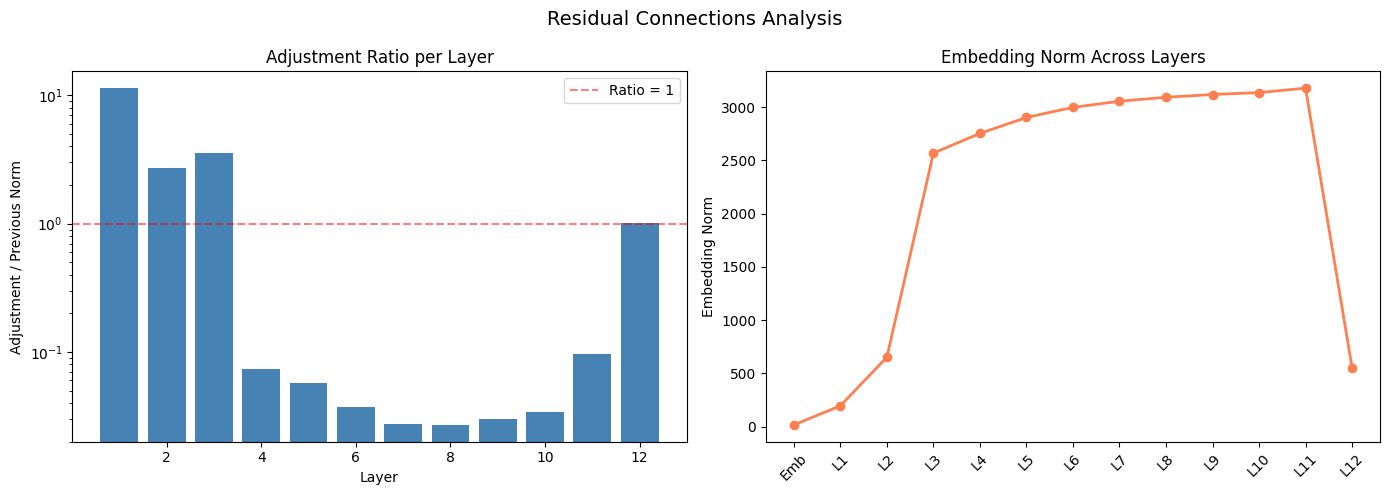

In [3]:
ratios = []
for i in range(1, 13):
    prev = hidden_states[i-1][0]
    curr = hidden_states[i][0]
    adj  = curr - prev
    ratios.append((adj.norm() / prev.norm()).item())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ratio plot
axes[0].bar(range(1, 13), ratios, color="steelblue")
axes[0].axhline(y=1, color="red", linestyle="--", 
                alpha=0.5, label="Ratio = 1")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Adjustment / Previous Norm")
axes[0].set_title("Adjustment Ratio per Layer")
axes[0].set_yscale("log")
axes[0].legend()

# Cumulative norm
norms = [hidden_states[i][0].norm().item() 
         for i in range(13)]
axes[1].plot(range(13), norms, 
             marker='o', color="coral", linewidth=2)
axes[1].set_xticks(range(13))
axes[1].set_xticklabels(
    ["Emb"] + [f"L{i}" for i in range(1, 13)], 
    rotation=45)
axes[1].set_ylabel("Embedding Norm")
axes[1].set_title("Embedding Norm Across Layers")

plt.suptitle("Residual Connections Analysis", fontsize=14)
plt.tight_layout()
plt.show()

* GPT-2 uses **residual connections** — each layer mainly makes small adjustments rather than completely changing the representation.
* **Early layers (1–3):** Large adjustments (**~11×**).
* **Middle layers (4–10):** Very small adjustments (**~0.03×**).
* **Last layer:** Large adjustment again.
* The **norm of representations keeps increasing** as we move through the layers.
